# Auto_OPDx — cross-modal alignment walkthrough

Rebuilding the per-cell labels for the "predict height from a photo" project.

**Why.** The labels the previous model trained on were built by cropping *raw*
height-map values around hand-placed centres. Two defects came with that:

1. **The substrate tilt was never removed.** A plane fit to the background spans
   a median of ~21 µm across a plate — about 71% of the raw z range. The
   resulting per-cell label correlates with the cell's **row index at r = +0.98**,
   so it largely encodes *where* a cell sits rather than *how tall* it is.
2. **Height-map cells were stretched to square.** A cell is only ~9 samples wide
   on the coarse axis, but the stored crops are ~70–108 columns. Most of that
   width is interpolated fiction. The 2880 stored crops have **534 distinct
   shapes**.

**What this notebook does.** Detrends against the fitted substrate plane, works
in physical micrometres, and registers the two modalities by fitting one 8×8
lattice to all 64 features at once.

Run top to bottom. Every figure is generated from the data in `data/`.

In [1]:
%matplotlib inline

import sys, warnings
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

REPO = Path.cwd()
while REPO != REPO.parent and not (REPO / "pyproject.toml").exists():
    REPO = REPO.parent
sys.path.insert(0, str(REPO / "src"))
warnings.filterwarnings("ignore", category=RuntimeWarning)

from Auto_OPDx.alignment import load_plate, detrend, load_rgb
from Auto_OPDx.alignment.lattice import detect_features, solve_lattice
from Auto_OPDx.alignment.rgb import dark_feature_response, detect_rgb_features
from Auto_OPDx.alignment.dataset import (
    solve_plate, solve_photo, fit_cross_modal, build_cells,
)

plt.rcParams.update({"figure.dpi": 100, "font.size": 9})
PLATE = "10-01-2025_P1"
OPDX = REPO / "data" / "opdx" / f"{PLATE}.OPDx"
print("repo:", REPO)
print("plate:", OPDX.name, "exists:", OPDX.exists())

repo: /Users/qpali/Auto_OPDx
plate: 10-01-2025_P1.OPDx exists: True


## 1. Geometry — the sampling is ~10.6× anisotropic

The stylus takes ~901 samples along its scan direction but only ~75 across it,
over a roughly square 2.2 × 2.6 mm field. That means **~2.9 µm per sample on one
axis and ~30 µm on the other**.

This is the reason the earlier attempt at rotation failed: rotating an array
that anisotropic while treating its cells as square necessarily turns squares
into parallelograms. No choice of transform fixes it downstream — you have to
work in physical coordinates.

In [2]:
p = load_plate(OPDX)
print(f"shape           {p.shape}")
print(f"x span          {np.ptp(p.x):8.1f} um over {p.x.size:4d} samples -> {p.dx:6.3f} um/sample")
print(f"y span          {np.ptp(p.y):8.1f} um over {p.y.size:4d} samples -> {p.dy:6.3f} um/sample")
print(f"ANISOTROPY      {p.anisotropy:.2f}x")
print(f"cell pitch      {np.ptp(p.x)/8:.1f} x {np.ptp(p.y)/8:.1f} um  (8x8 grid)")
print(f"samples/cell    {np.ptp(p.x)/8/p.dx:.1f} (x) x {np.ptp(p.y)/8/p.dy:.1f} (y)")

shape           (901, 75)
x span            2240.6 um over   75 samples -> 30.279 um/sample
y span            2590.0 um over  901 samples ->  2.878 um/sample
ANISOTROPY      10.52x
cell pitch      280.1 x 323.8 um  (8x8 grid)
samples/cell    9.2 (x) x 112.5 (y)


## 2. The substrate tilt — this is the whole problem

Left panel: raw z. The features are barely visible against the gradient.
Right panel: the same data after subtracting the fitted plane. All 64 pop out.

The plane is fit to the **background only** (samples at or below the 45th
percentile), so the raised features don't drag it upward. That makes the
subtracted surface the true substrate, and the residual the true polymer
thickness.

  tilt_pp_um               19.780
  gradient_um_per_mm        7.628
  raw_pp_um                29.460
  resid_pp_um              13.542
  tilt_fraction             0.671

  tilt is 67% of the raw z range


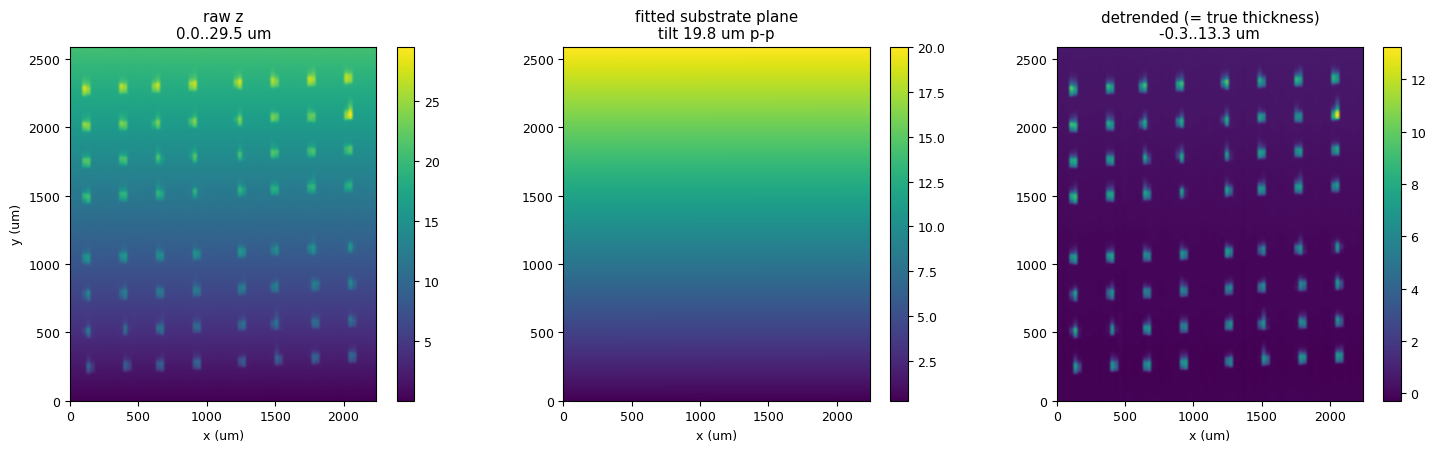

In [3]:
resid, info = detrend(p)
for k, v in info.items():
    print(f"  {k:22} {v:8.3f}")
print(f"\n  tilt is {info['tilt_fraction']*100:.0f}% of the raw z range")

from Auto_OPDx.alignment.plate import fit_background_plane, plane_surface
coef, icept = fit_background_plane(p)
plane = plane_surface(p, coef, icept)

fig, ax = plt.subplots(1, 3, figsize=(15, 4.6))
for a, (img, t) in zip(ax, [
    (p.z,    f"raw z\n{p.z.min():.1f}..{p.z.max():.1f} um"),
    (plane,  f"fitted substrate plane\ntilt {info['tilt_pp_um']:.1f} um p-p"),
    (resid,  f"detrended (= true thickness)\n{resid.min():.1f}..{resid.max():.1f} um"),
]):
    im = a.imshow(img, cmap="viridis", origin="lower", extent=p.extent, aspect="equal")
    a.set_title(t); a.set_xlabel("x (um)")
    fig.colorbar(im, ax=a, fraction=0.046)
ax[0].set_ylabel("y (um)")
fig.tight_layout()

## 3. Why per-feature centroids can't work — and what to do instead

A feature is ~98 µm square, but the coarse axis samples every ~30 µm, so a
feature spans only **2–3 samples** there. A centroid from 3 samples cannot beat
roughly **±15 µm**, which is ~5% of the cell pitch.

The way out comes from the fabrication process: the grid is written by a **DMD
through a 4× objective onto a piezostage**, so its pitch is deterministic by
construction. That justifies fitting **one rigid lattice to all 64 features at
once** — 10 parameters instead of 128 free coordinates — which averages the
per-feature quantisation noise down by ~√64 = 8×.

The model, per output axis:

$$\text{pos} = a\,r + b\,c + d\,[r \ge 4] + e\,[c \ge 4] + f$$

Five parameters per axis. This spans translation, independent scale on each grid
axis, rotation and shear (via the cross terms), and the **quadrant gaps** visible
between rows/columns 3 and 4.

In [4]:
thr = max(2.0, float(np.percentile(resid, 99.0)) * 0.30)
centres, areas = detect_features(resid, p.x, p.y, threshold=thr, min_area_px=6)
fit_h = solve_lattice(centres, 8, 8)

print(f"threshold        {thr:.2f} um")
print(f"blobs found      {len(centres)}  (median area {np.median(areas):.0f} px)")
print(f"feature size     ~{np.median(areas)**0.5 * (p.dx*p.dy)**0.5:.0f} um equivalent square")
print(f"\n{fit_h.summary()}   [units: um]")
print(f"\nsingle-feature quantisation limit  ~+/-{max(p.dx,p.dy)/2:5.1f} um")
print(f"achieved lattice rmse              ~+/-{fit_h.rmse:5.1f} um")
print(f"                                    {fit_h.rmse/np.mean(fit_h.pitch)*100:.1f}% of cell pitch")

threshold        2.00 um
blobs found      64  (median area 60 px)
feature size     ~72 um equivalent square

lattice 8x8: 64/64 inliers (expected 64), rmse 7.24, max 16.88, pitch 268.2/264.7, rot +2.35 deg   [units: um]

single-feature quantisation limit  ~+/- 15.1 um
achieved lattice rmse              ~+/-  7.2 um
                                    2.7% of cell pitch


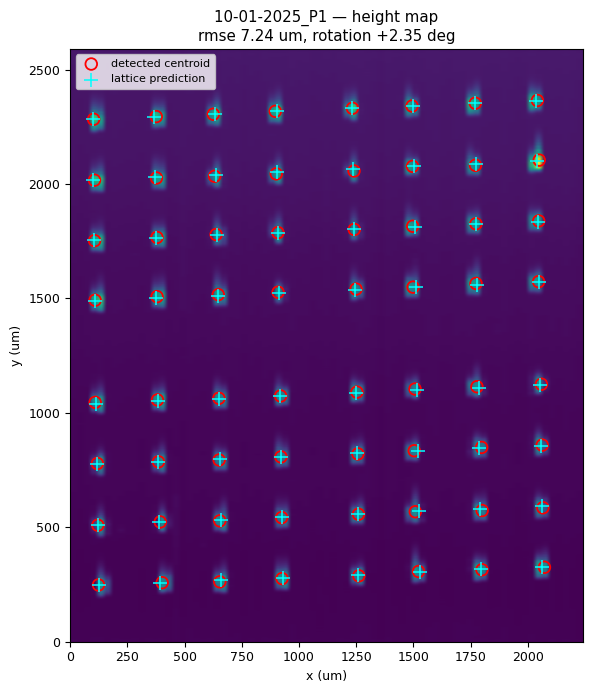

In [5]:
pred = fit_h.all_centres()
fig, ax = plt.subplots(figsize=(6.5, 7))
ax.imshow(resid, cmap="viridis", origin="lower", extent=p.extent, aspect="equal")
ax.scatter(centres[:, 0], centres[:, 1], s=70, facecolors="none",
           edgecolors="red", lw=1.3, label="detected centroid")
ax.scatter(pred[:, 0], pred[:, 1], marker="+", s=90, c="cyan", lw=1.1,
           label="lattice prediction")
ax.set_title(f"{PLATE} — height map\nrmse {fit_h.rmse:.2f} um, "
             f"rotation {fit_h.rotation_deg:+.2f} deg")
ax.set_xlabel("x (um)"); ax.set_ylabel("y (um)")
ax.legend(loc="upper left", fontsize=8)
fig.tight_layout()

## 4. The photo side — two bugs in the previous detector

**Polarity.** The features are *dark* squares on a *bright* substrate. A white
top-hat (as in `calculate_brightness.tophat_response`) detects bright-on-dark,
i.e. the wrong sign.

**Illumination.** The response is far stronger on one side of the plate, so a
global percentile threshold detects mostly features from the bright side and
biases the grid fit. Dividing by a heavily blurred copy normalises contrast
before thresholding.

Fixing both took the photo lattice residual from **108 px → ~3 px**.

image            (1536, 2048, 3)  (.jpg)
blobs found      69 (median area 3564 px)

lattice 8x8: 62/69 inliers (expected 64), rmse 3.00, max 7.38, pitch 249.5/182.1, rot -0.16 deg   [units: px]


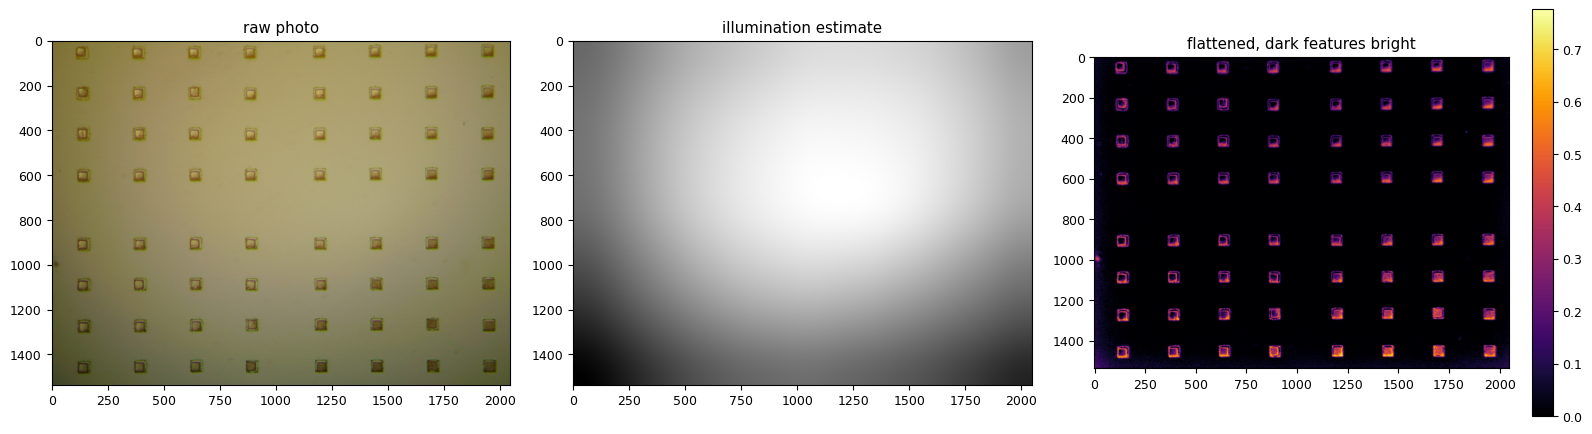

In [6]:
img_path = next(q for q in (REPO/"data"/"rgb"/"img").iterdir() if q.stem == PLATE)
img = load_rgb(img_path)
dark, background = dark_feature_response(img)
centres_r, areas_r, _ = detect_rgb_features(img)
fit_r = solve_lattice(centres_r, 8, 8)

print(f"image            {img.shape}  ({img_path.suffix})")
print(f"blobs found      {len(centres_r)} (median area {np.median(areas_r):.0f} px)")
print(f"\n{fit_r.summary()}   [units: px]")

fig, ax = plt.subplots(1, 3, figsize=(16, 4.4))
ax[0].imshow(img);                      ax[0].set_title("raw photo")
ax[1].imshow(background, cmap="gray");  ax[1].set_title("illumination estimate")
im = ax[2].imshow(dark, cmap="inferno"); ax[2].set_title("flattened, dark features bright")
fig.colorbar(im, ax=ax[2], fraction=0.046)
fig.tight_layout()

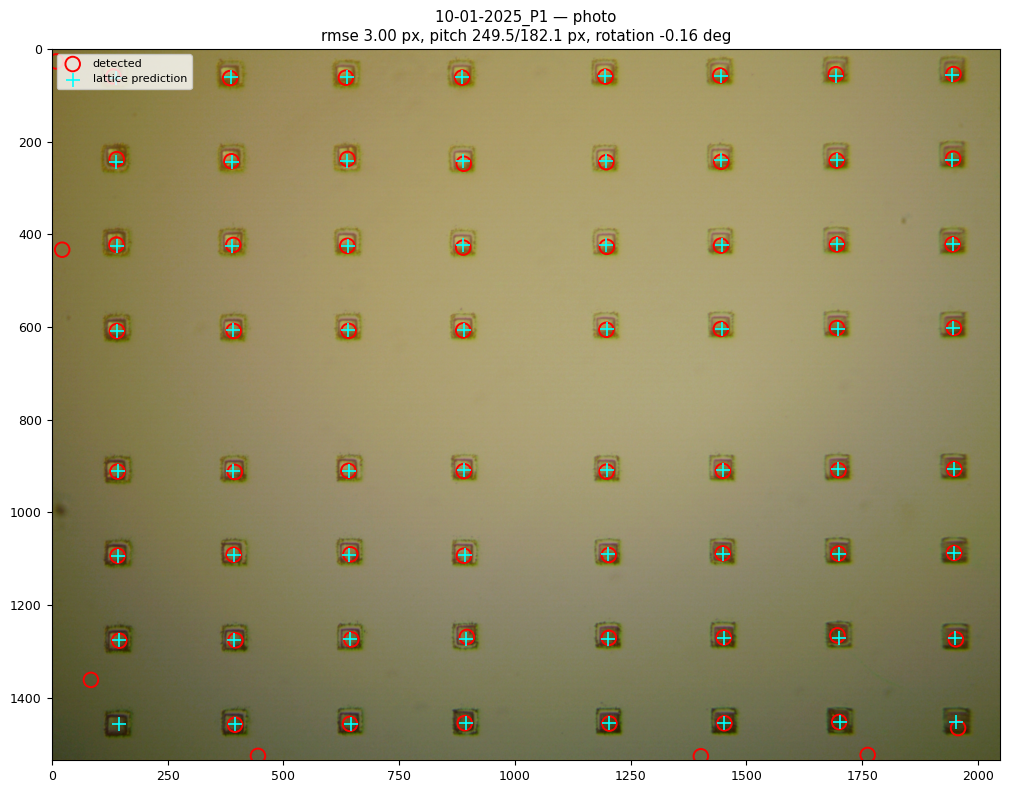

In [7]:
pred_r = fit_r.all_centres()
fig, ax = plt.subplots(figsize=(11, 8))
ax.imshow(img)
ax.scatter(centres_r[:, 0], centres_r[:, 1], s=110, facecolors="none",
           edgecolors="red", lw=1.4, label="detected")
ax.scatter(pred_r[:, 0], pred_r[:, 1], marker="+", s=110, c="cyan", lw=1.2,
           label="lattice prediction")
ax.set_title(f"{PLATE} — photo\nrmse {fit_r.rmse:.2f} px, "
             f"pitch {fit_r.pitch[0]:.1f}/{fit_r.pitch[1]:.1f} px, "
             f"rotation {fit_r.rotation_deg:+.2f} deg")
ax.legend(loc="upper left", fontsize=8)
fig.tight_layout()

## 5. Cross-modal registration — and a hidden distortion

Both lattices are indexed by the same `(row, col)`, so **correspondence is
free** — no image feature matching required. Six affine parameters are fit from
up to 64 point pairs.

The reported residual deliberately uses the *detected* centroids on both sides,
not the lattice predictions. Comparing predictions to predictions would flatter
the result, since both are smooth models of the same grid.

Watch the pixel aspect ratio in the output. The photo's pitch is ~250 × 182 px
while the physical grid is square, so **the photo's pixel scale differs ~1.36×
between axes** — the stored 2048×1536 image covers a nearly square field.
A square *pixel* crop is therefore a non-square *physical* region, which is a
second distortion in the previous per-cell crops.

In [8]:
hm = solve_plate(OPDX)
ph = solve_photo(img_path)
cm = fit_cross_modal(hm, ph)

print(f"slots matched      {len(cm.slots)} / 64")
print(f"CROSS-MODAL rmse   {cm.rmse_um:6.2f} um     <- the headline registration number")
print(f"worst cell         {cm.max_um:6.2f} um")
print(f"  as % of pitch    {cm.rmse_um/np.mean(hm.fit.pitch)*100:6.2f}%")
print()
print(f"um per px, x       {cm.um_per_px[0]:6.4f}")
print(f"um per px, y       {cm.um_per_px[1]:6.4f}")
print(f"PIXEL ASPECT (y/x) {cm.um_per_px[1]/cm.um_per_px[0]:6.3f}   <- not 1.0; square px != square um")
print(f"relative rotation  {cm.rotation_deg:+6.2f} deg")
print()
print(f"physical field     {img.shape[1]*cm.um_per_px[0]:.0f} x {img.shape[0]*cm.um_per_px[1]:.0f} um"
      "   (nearly square, unlike the 4:3 pixel array)")

slots matched      62 / 64
CROSS-MODAL rmse     7.65 um     <- the headline registration number
worst cell          15.37 um
  as % of pitch      2.87%

um per px, x       1.0735
um per px, y       1.4610
PIXEL ASPECT (y/x)  1.361   <- not 1.0; square px != square um
relative rotation   +2.62 deg

physical field     2198 x 2244 um   (nearly square, unlike the 4:3 pixel array)


## 6. The cells — matched crops, square in micrometres

Each crop is a physically square window centred on the lattice prediction for
its `(row, col)`. Crops keep the full cell pitch: the results deck found
surrounding context to be genuine signal (tightening crops 40% dropped per-cell
R² from 0.77 to 0.59).

`overhang` records how much of a requested window fell outside the data. The
photo clips the top and bottom rows of the grid, so border cells are flagged
rather than silently truncated.

In [9]:
cells = build_cells(hm, ph, cm, label_um=110.0)
print(f"cells            {len(cells)}")
print(f"with rgb crop    {sum(c.rgb is not None for c in cells)}")
print(f"zero overhang    {sum(c.overhang == 0 for c in cells)}")
print(f"overhang < 10%   {sum(c.overhang < 0.10 for c in cells)}")
c0 = cells[0]
print(f"\nsample {c0.name}: rgb {c0.rgb.shape}, height {c0.height.shape}")
print("labels:", {k: (round(v, 3) if isinstance(v, float) else v) for k, v in c0.labels.items()})

cells            64
with rgb crop    64
zero overhang    36
overhang < 10%   48

sample 10-01-2025_P1_r00_c00: rgb (96, 96, 3), height (32, 32)
labels: {'h_max': 7.048, 'h_p95': 6.751, 'h_top10_mean': 6.698, 'h_mean': 2.078, 'n_px': 114}


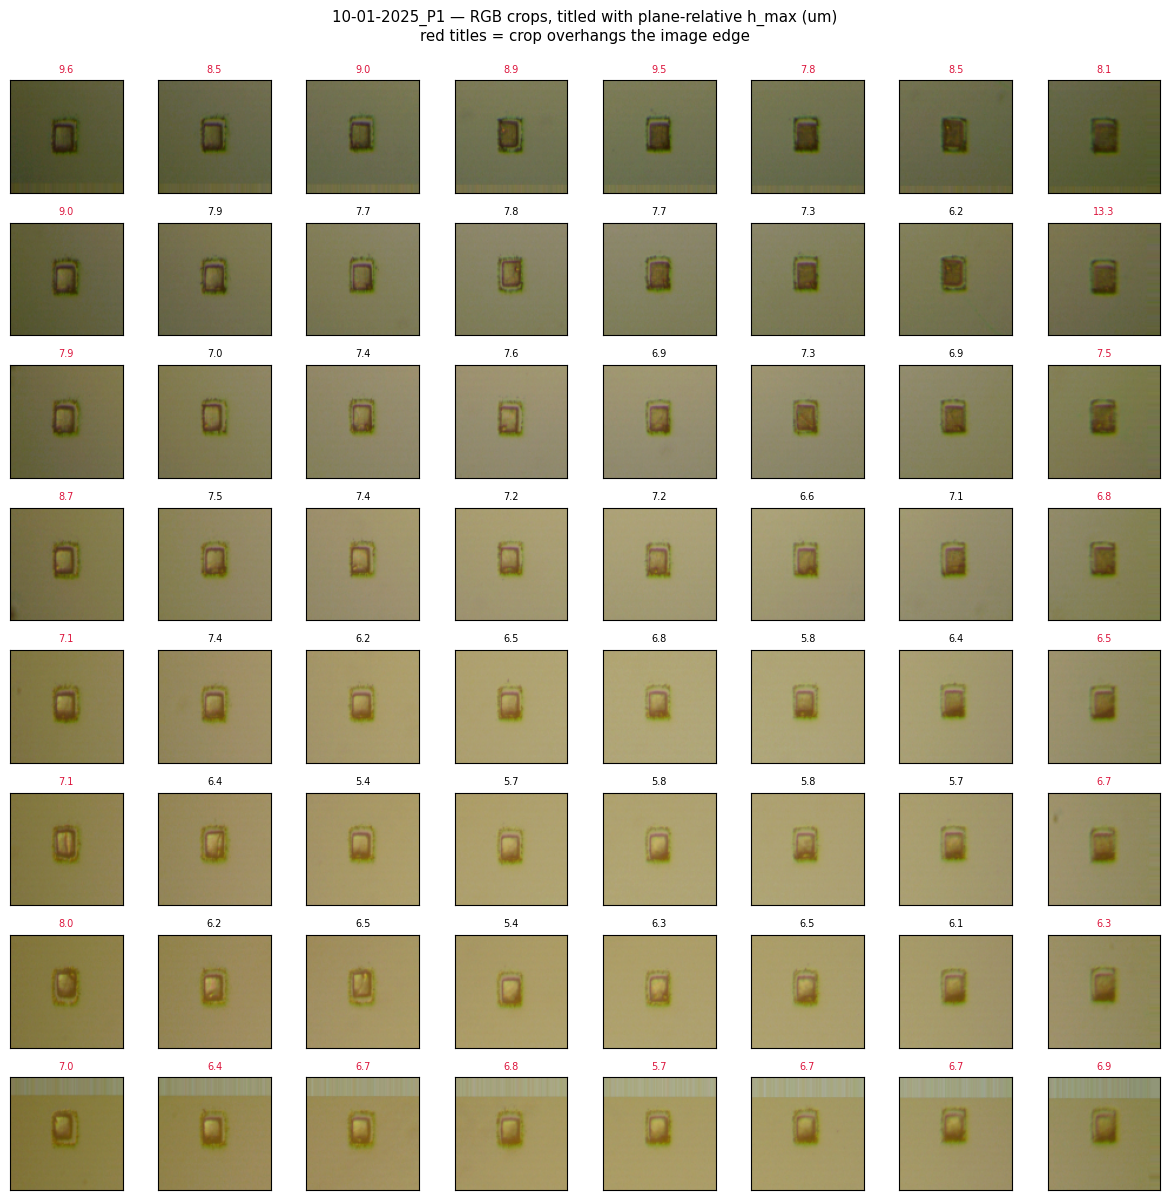

In [10]:
# 8x8 montage of RGB crops, annotated with the plane-relative label
fig, axes = plt.subplots(8, 8, figsize=(12, 12))
for c in cells:
    a = axes[7 - c.row][c.col]          # row 0 at the bottom, as in the height map
    if c.rgb is not None:
        a.imshow(c.rgb)
    a.set_xticks([]); a.set_yticks([])
    h = c.labels.get("h_max")
    if h is not None:
        a.set_title(f"{h:.1f}", fontsize=7,
                    color="black" if c.overhang == 0 else "crimson")
fig.suptitle(f"{PLATE} — RGB crops, titled with plane-relative h_max (um)\n"
             "red titles = crop overhangs the image edge", y=0.995)
fig.tight_layout()

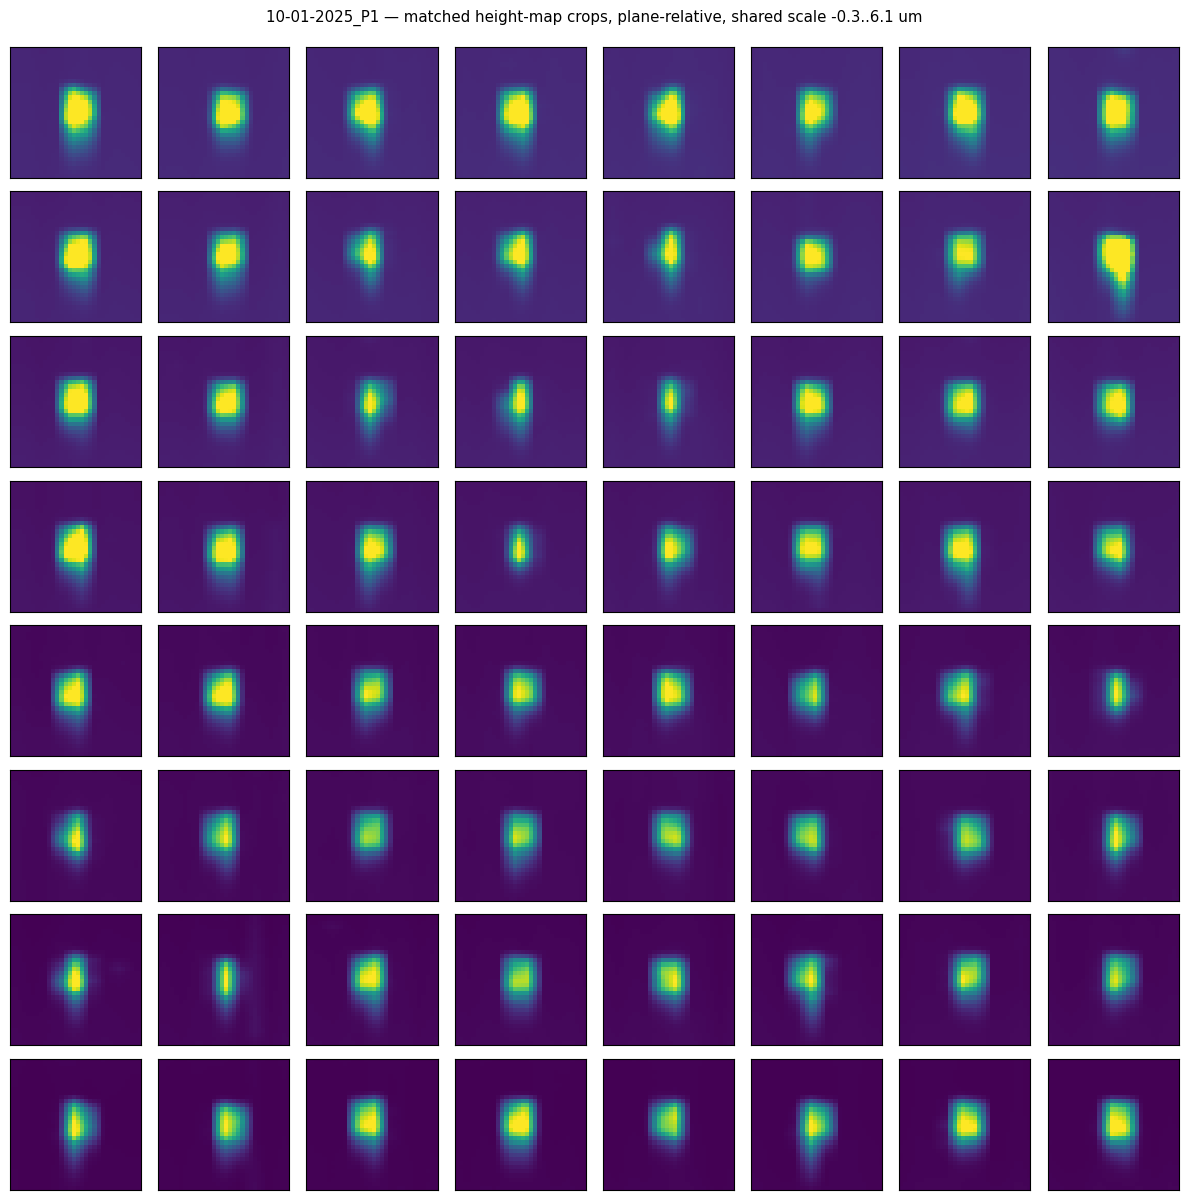

In [11]:
# The same cells as height maps, on one shared colour scale
vals = np.concatenate([c.height[np.isfinite(c.height)].ravel()
                       for c in cells if c.height is not None])
vmin, vmax = np.percentile(vals, [1, 99])
fig, axes = plt.subplots(8, 8, figsize=(12, 12))
for c in cells:
    a = axes[7 - c.row][c.col]
    if c.height is not None:
        a.imshow(c.height, cmap="viridis", vmin=vmin, vmax=vmax)
    a.set_xticks([]); a.set_yticks([])
fig.suptitle(f"{PLATE} — matched height-map crops, plane-relative, "
             f"shared scale {vmin:.1f}..{vmax:.1f} um", y=0.995)
fig.tight_layout()

## 7. Old labels vs new — the position confound

This is the result that matters.

For each cell, take the label and correlate it against the cell's **row index**.
A label that measures thickness should show only whatever gradient the
experiment actually built in. A label contaminated by substrate tilt will track
row position almost perfectly, because the tilt runs along the stylus scan axis.

                                  raw z   plane-relative
corr(row, label)                 +0.986           +0.643
corr(col, label)                 +0.009           -0.115
R2 from position alone            0.971            0.426
label range (um)                  21.32             7.89


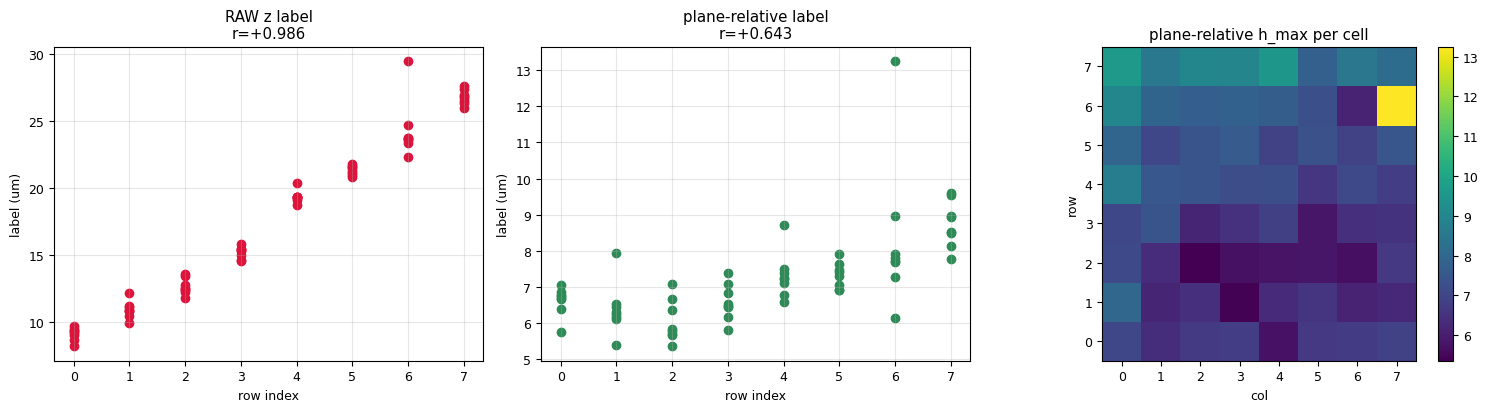

In [12]:
rr = np.array([c.row for c in cells])
cc = np.array([c.col for c in cells])

# old-style label: max of RAW z in the same window
old = []
for c in cells:
    hx, hy = hm.fit.predict((c.row, c.col))[0]
    xi = np.where(np.abs(hm.plate.x - hx) <= 55)[0]
    yi = np.where(np.abs(hm.plate.y - hy) <= 55)[0]
    old.append(hm.plate.z[np.ix_(yi, xi)].max() if xi.size and yi.size else np.nan)
old = np.array(old)
new = np.array([c.labels.get("h_max", np.nan) for c in cells])
g = np.isfinite(old) & np.isfinite(new)

def pos_r2(v):
    A = np.c_[rr[g], cc[g], np.ones(g.sum())]
    pred = A @ np.linalg.lstsq(A, v[g], rcond=None)[0]
    return 1 - ((v[g]-pred)**2).sum() / ((v[g]-v[g].mean())**2).sum()

print(f"{'':26} {'raw z':>12} {'plane-relative':>16}")
print(f"{'corr(row, label)':26} {np.corrcoef(rr[g],old[g])[0,1]:+12.3f} {np.corrcoef(rr[g],new[g])[0,1]:+16.3f}")
print(f"{'corr(col, label)':26} {np.corrcoef(cc[g],old[g])[0,1]:+12.3f} {np.corrcoef(cc[g],new[g])[0,1]:+16.3f}")
print(f"{'R2 from position alone':26} {pos_r2(old):12.3f} {pos_r2(new):16.3f}")
print(f"{'label range (um)':26} {np.ptp(old[g]):12.2f} {np.ptp(new[g]):16.2f}")

fig, ax = plt.subplots(1, 3, figsize=(15, 4.2))
ax[0].scatter(rr[g], old[g], c="crimson"); ax[0].set_title(f"RAW z label\nr={np.corrcoef(rr[g],old[g])[0,1]:+.3f}")
ax[1].scatter(rr[g], new[g], c="seagreen"); ax[1].set_title(f"plane-relative label\nr={np.corrcoef(rr[g],new[g])[0,1]:+.3f}")
for a in ax[:2]:
    a.set_xlabel("row index"); a.set_ylabel("label (um)"); a.grid(alpha=.3)
M = np.full((8, 8), np.nan)
for c, v in zip(cells, new):
    M[c.row, c.col] = v
im = ax[2].imshow(M, origin="lower", cmap="viridis")
ax[2].set_title("plane-relative h_max per cell"); ax[2].set_xlabel("col"); ax[2].set_ylabel("row")
fig.colorbar(im, ax=ax[2], fraction=0.046)
fig.tight_layout()

### Why a plane and not a higher-order surface?

Worth checking, since a bowed wafer would need more than a plane. It doesn't
help — a quadratic makes the row correlation *worse*, and a cubic starts
absorbing the features themselves and produces physically impossible **negative**
thicknesses. The background really is planar.

In [13]:
xm, ym = p.mesh()
bg = p.z <= np.percentile(p.z, 45)

def resid_order(order):
    X, Y = xm[bg], ym[bg]
    cols_ = [np.ones(bg.sum()), X, Y]
    full  = [np.ones_like(xm), xm, ym]
    if order >= 2:
        cols_ += [X*X, Y*Y, X*Y];       full += [xm*xm, ym*ym, xm*ym]
    if order >= 3:
        cols_ += [X**3, Y**3, X*X*Y, X*Y*Y]
        full  += [xm**3, ym**3, xm*xm*ym, xm*ym*ym]
    k, *_ = np.linalg.lstsq(np.column_stack(cols_), p.z[bg], rcond=None)
    return p.z - sum(ki*fi for ki, fi in zip(k, full))

print(f"{'surface':>10} {'corr(row,h_max)':>16} {'min label um':>14}")
for order, nm in ((1, "plane"), (2, "quadratic"), (3, "cubic")):
    R = resid_order(order)
    lab = []
    for c in cells:
        hx, hy = hm.fit.predict((c.row, c.col))[0]
        xi = np.where(np.abs(p.x-hx) <= 55)[0]; yi = np.where(np.abs(p.y-hy) <= 55)[0]
        if xi.size and yi.size: lab.append(R[np.ix_(yi, xi)].max())
    lab = np.array(lab)
    flag = "  <- negative thickness is impossible" if lab.min() < 0 else ""
    print(f"{nm:>10} {np.corrcoef(rr[:len(lab)], lab)[0,1]:+16.3f} {lab.min():14.2f}{flag}")

   surface  corr(row,h_max)   min label um
     plane           +0.643           5.36
 quadratic           +0.793           5.31
     cubic           -0.742          -1.10  <- negative thickness is impossible


## 8. Batch view — does this hold across all 69 plates?

One plate proves nothing. This sweeps every plate and reports the distribution.
Takes a couple of minutes.

For the full comparison against the previously stored centroids, run:

```bash
uv run python scripts/02_validate_alignment.py
```

In [14]:
rows_out = []
opdx_files = sorted((REPO/"data"/"opdx").glob("*.OPDx"))
for i, path in enumerate(opdx_files):
    try:
        s = solve_plate(path)
    except Exception as e:
        print(f"  skip {path.stem}: {type(e).__name__}"); continue
    lab_new, lab_old, rws, cls = [], [], [], []
    for r in range(8):
        for c in range(8):
            hx, hy = s.fit.predict((r, c))[0]
            xi = np.where(np.abs(s.plate.x-hx) <= 55)[0]
            yi = np.where(np.abs(s.plate.y-hy) <= 55)[0]
            if not (xi.size and yi.size): continue
            sl = np.ix_(yi, xi)
            lab_new.append(s.resid[sl].max()); lab_old.append(s.plate.z[sl].max())
            rws.append(r); cls.append(c)
    if len(lab_new) < 20: continue
    ln, lo = np.array(lab_new), np.array(lab_old)
    rws, cls = np.array(rws), np.array(cls)
    A = np.c_[rws, cls, np.ones(len(rws))]
    def r2(v):
        pr = A @ np.linalg.lstsq(A, v, rcond=None)[0]
        return 1 - ((v-pr)**2).sum()/((v-v.mean())**2).sum()
    rows_out.append(dict(
        plate=s.plate.name, rmse=s.fit.rmse, pitch=float(np.mean(s.fit.pitch)),
        tilt=s.tilt["tilt_pp_um"], tfrac=s.tilt["tilt_fraction"],
        r2_old=r2(lo), r2_new=r2(ln),
        row_old=np.corrcoef(rws, lo)[0, 1], row_new=np.corrcoef(rws, ln)[0, 1],
        col_old=np.corrcoef(cls, lo)[0, 1], col_new=np.corrcoef(cls, ln)[0, 1],
    ))
    if (i+1) % 20 == 0: print(f"  {i+1}/{len(opdx_files)}")
print(f"done: {len(rows_out)} plates")

  20/69


  40/69


  60/69


done: 69 plates


R^2 PREDICTABLE FROM (row, col) POSITION ALONE
  raw z labels       median 0.958   >0.83 on 63/69
  plane-relative     median 0.402   >0.83 on 9/69

  Row position alone reaches R^2 ~0.96 on the raw labels -- ABOVE the
  0.83 the previous model reported. On those labels a high R^2 therefore
  does not demonstrate that anything learned thickness.

IS THE GRADIENT DIRECTION CONSISTENT?  (tilt: yes / design: no)
  raw z      row-corr median +0.966, positive on 69/69
             dominant axis: row on 69, col on 0
  plane-rel  row-corr median +0.311, positive on 54/69
             dominant axis: row on 37, col on 32

  Raw: always row-dominant, always positive -> the substrate tilt, which
  always runs along the stylus scan axis.
  Plane-relative: direction splits ~50/50 -> the formulation layout, which
  differs per plate. Artifact and real signal, separated.


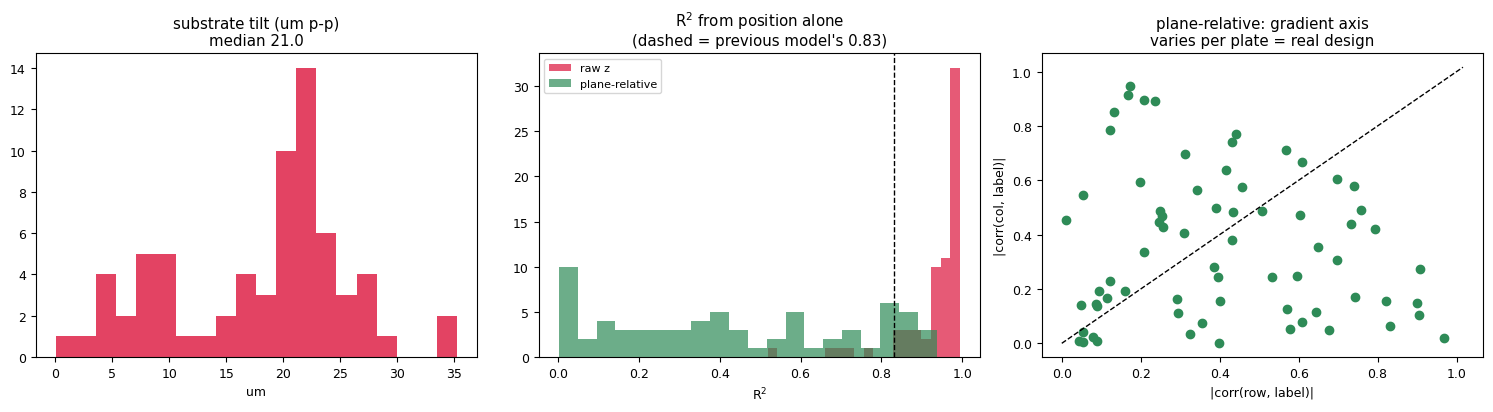

In [15]:
g = lambda k: np.array([r[k] for r in rows_out], float)

print("=" * 68)
print("R^2 PREDICTABLE FROM (row, col) POSITION ALONE")
print("=" * 68)
for k, nm in (("r2_old", "raw z labels"), ("r2_new", "plane-relative")):
    v = g(k)
    print(f"  {nm:18} median {np.median(v):.3f}   >0.83 on {int((v>0.83).sum())}/{len(v)}")
print("\n  Row position alone reaches R^2 ~0.96 on the raw labels -- ABOVE the")
print("  0.83 the previous model reported. On those labels a high R^2 therefore")
print("  does not demonstrate that anything learned thickness.")

print("\n" + "=" * 68)
print("IS THE GRADIENT DIRECTION CONSISTENT?  (tilt: yes / design: no)")
print("=" * 68)
for tag, nm in (("old", "raw z"), ("new", "plane-rel")):
    ro, co_ = g(f"row_{tag}"), g(f"col_{tag}")
    dom = np.abs(ro) > np.abs(co_)
    print(f"  {nm:10} row-corr median {np.median(ro):+.3f}, positive on {int((ro>0).sum())}/{len(ro)}")
    print(f"  {'':10} dominant axis: row on {int(dom.sum())}, col on {int((~dom).sum())}")
print("\n  Raw: always row-dominant, always positive -> the substrate tilt, which")
print("  always runs along the stylus scan axis.")
print("  Plane-relative: direction splits ~50/50 -> the formulation layout, which")
print("  differs per plate. Artifact and real signal, separated.")

fig, ax = plt.subplots(1, 3, figsize=(15, 4.2))
ax[0].hist(g("tilt"), bins=20, color="crimson", alpha=.8)
ax[0].set_title(f"substrate tilt (um p-p)\nmedian {np.median(g('tilt')):.1f}")
ax[0].set_xlabel("um")
ax[1].hist(g("r2_old"), bins=20, alpha=.7, label="raw z", color="crimson")
ax[1].hist(g("r2_new"), bins=20, alpha=.7, label="plane-relative", color="seagreen")
ax[1].axvline(0.83, ls="--", c="k", lw=1)
ax[1].set_title("R$^2$ from position alone\n(dashed = previous model's 0.83)")
ax[1].set_xlabel("R$^2$"); ax[1].legend(fontsize=8)
ax[2].scatter(np.abs(g("row_new")), np.abs(g("col_new")), c="seagreen")
lim = max(np.abs(g("row_new")).max(), np.abs(g("col_new")).max()) * 1.05
ax[2].plot([0, lim], [0, lim], "k--", lw=1)
ax[2].set_xlabel("|corr(row, label)|"); ax[2].set_ylabel("|corr(col, label)|")
ax[2].set_title("plane-relative: gradient axis\nvaries per plate = real design")
fig.tight_layout()

## Summary

| | before | after |
|---|---|---|
| labels | raw `z_max`, tilt included | plane-relative |
| R² from position alone | **0.96** | **0.40** |
| gradient direction | row on 69/69 (artifact) | row 37 / col 32 (real) |
| height-crop shapes | **534 distinct** | one fixed shape |
| crop geometry | square in pixels | square in **micrometres** |
| feature localisation | per-feature centroid, ±15 µm limit | joint 64-feature lattice, ~7 µm |
| cross-modal registration | not measured | ~8 µm rmse (3% of cell pitch) |

**What this changes.** The previous benchmark of R² = 0.83 sat *below* the 0.96
obtainable from row position alone, so it was not evidence of learning
thickness. On the rebuilt labels the position-only baseline is 0.40 — and a
model that beats *that* is measuring something real.

**Next.** Re-run the DINOv2 pipeline on these labels and see how many control
points are actually needed. The hypothesis is that the requirement drops from 8
toward 2–3, because the label error that forced 8 was position leakage rather
than an intrinsic limit.